<a href="https://colab.research.google.com/github/Uday1993-deepika/Recommendation-system/blob/main/Recomndation_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#SVD RECOMMENDATION SYSTEM
#  Columns expected: UserId | ProductId | Rating | Timestamp
# ================================================================

# ── Cell 1 · Imports ─────────────────────────────────────────
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from math import sqrt
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
import warnings
warnings.filterwarnings("ignore")

print("✅ Libraries loaded")

✅ Libraries loaded


In [2]:
df = pd.read_csv("/content/ratings_Beauty.csv")

In [3]:
print(df.head())

           UserId   ProductId  Rating   Timestamp
0  A39HTATAQ9V7YF  0205616461     5.0  1369699200
1  A3JM6GV9MNOF9X  0558925278     3.0  1355443200
2  A1Z513UWSAAO0F  0558925278     5.0  1404691200
3  A1WMRR494NWEWV  0733001998     4.0  1382572800
4  A3IAAVS479H7M7  0737104473     1.0  1274227200


In [4]:
print("Shape:", df.shape)

Shape: (2023070, 4)


In [5]:
# ── 2. BASIC EXPLORATION ──────────────────────────────────────

print("\n--- Basic Info ---")
print(f"Total interactions : {len(df):,}")
print(f"Unique users       : {df['UserId'].nunique():,}")
print(f"Unique products    : {df['ProductId'].nunique():,}")
print(f"Rating range       : {df['Rating'].min()} – {df['Rating'].max()}")
print(f"Missing values     :\n{df.isnull().sum()}")


--- Basic Info ---
Total interactions : 2,023,070
Unique users       : 1,210,271
Unique products    : 249,274
Rating range       : 1.0 – 5.0
Missing values     :
UserId       0
ProductId    0
Rating       0
Timestamp    0
dtype: int64


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2023070 entries, 0 to 2023069
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   UserId     object 
 1   ProductId  object 
 2   Rating     float64
 3   Timestamp  int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 61.7+ MB


** Cleaning The Data **

In [7]:
##Convert Unix timestamp to readable date

df["date"] = pd.to_datetime(df["Timestamp"], unit="s")
print(df["date"])

0         2013-05-28
1         2012-12-14
2         2014-07-07
3         2013-10-24
4         2010-05-19
             ...    
2023065   2014-07-14
2023066   2014-07-14
2023067   2014-07-15
2023068   2014-07-17
2023069   2014-07-18
Name: date, Length: 2023070, dtype: datetime64[ns]


In [8]:
 # Drop duplicates (same user rating same product twice)
df = df.drop_duplicates(subset=["UserId", "ProductId"])

In [9]:
# Keep only users with at least 5 interactions (reduces sparsity)
user_counts = df["UserId"].value_counts()
active_users = user_counts[user_counts >= 5].index
df = df[df["UserId"].isin(active_users)]

In [10]:
# Keep only products with at least 5 ratings
product_counts = df["ProductId"].value_counts()
active_products = product_counts[product_counts >= 5].index
df = df[df["ProductId"].isin(active_products)]

print(f"\nAfter filtering:")
print(f"Interactions : {len(df):,}")
print(f"Users        : {df['UserId'].nunique():,}")
print(f"Products     : {df['ProductId'].nunique():,}")


After filtering:
Interactions : 313,823
Users        : 51,369
Products     : 19,369


In [11]:
# ── Cell 2 · Quick EDA ───────────────────────────────────────
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Shape            : {df.shape}")
print(f"Users            : {df['UserId'].nunique():,}")
print(f"Products         : {df['ProductId'].nunique():,}")
print(f"Ratings          : {len(df):,}")
print(f"Rating range     : {df['Rating'].min()} – {df['Rating'].max()}")
print(f"Avg rating       : {df['Rating'].mean():.2f}")
print(f"Missing values   :\n{df.isnull().sum()}")

DATASET OVERVIEW
Shape            : (313823, 5)
Users            : 51,369
Products         : 19,369
Ratings          : 313,823
Rating range     : 1.0 – 5.0
Avg rating       : 4.20
Missing values   :
UserId       0
ProductId    0
Rating       0
Timestamp    0
date         0
dtype: int64


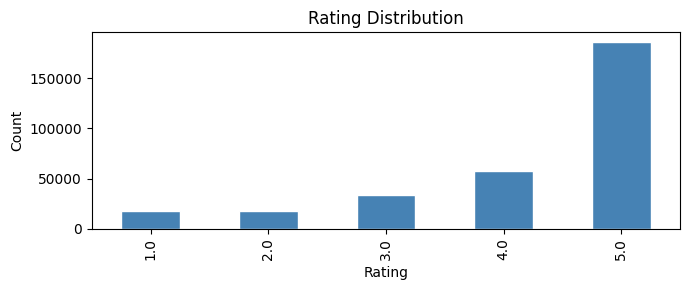

In [12]:
# Rating distribution plot
plt.figure(figsize=(7, 3))
df["Rating"].value_counts().sort_index().plot(kind="bar", color="steelblue", edgecolor="white")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [13]:
# ── Cell 3 · Filter & Deduplicate ────────────────────────────
def iterative_filter(df, min_ratings=5):
    """Remove users/products with < min_ratings until stable."""
    rounds = 0
    while True:
        before = len(df)
        p_counts = df["ProductId"].value_counts()
        df = df[df["ProductId"].isin(p_counts[p_counts >= min_ratings].index)]
        u_counts = df["UserId"].value_counts()
        df = df[df["UserId"].isin(u_counts[u_counts >= min_ratings].index)]
        rounds += 1
        if len(df) == before:
            break
    print(f"  Converged in {rounds} round(s)")
    return df

df = iterative_filter(df, min_ratings=5)

  Converged in 9 round(s)


In [14]:
# Average duplicate (UserId, ProductId) pairs
df = df.groupby(["UserId", "ProductId"], as_index=False).agg(
    Rating=("Rating", "mean"),
    Timestamp=("Timestamp", "max"),   # keep most recent
)

print(f"\nAfter filtering & dedup:")
print(f"  Interactions : {len(df):,}")
print(f"  Users        : {df['UserId'].nunique():,}")
print(f"  Products     : {df['ProductId'].nunique():,}")
sparsity = 1 - len(df) / (df["UserId"].nunique() * df["ProductId"].nunique())
print(f"  Sparsity     : {sparsity:.2%}")


After filtering & dedup:
  Interactions : 198,502
  Users        : 22,363
  Products     : 12,101
  Sparsity     : 99.93%


In [15]:
# ── Cell 4 · Encode IDs ──────────────────────────────────────
user_ids    = df["UserId"].unique()
product_ids = df["ProductId"].unique()

user2idx    = {u: i for i, u in enumerate(user_ids)}
product2idx = {p: i for i, p in enumerate(product_ids)}
idx2user    = {i: u for u, i in user2idx.items()}
idx2product = {i: p for p, i in product2idx.items()}

df["user_idx"]    = df["UserId"].map(user2idx)
df["product_idx"] = df["ProductId"].map(product2idx)

n_users    = len(user_ids)
n_products = len(product_ids)

print(f"Encoded {n_users:,} users  ×  {n_products:,} products")

Encoded 22,363 users  ×  12,101 products


In [16]:
# ── Cell 5 · Optional: Temporal Weight Column ────────────────
# Newer interactions get a higher weight (0.5 – 1.0 range).
# This will be used during matrix construction below.
t_min = df["Timestamp"].min()
t_max = df["Timestamp"].max()
df["time_weight"] = 0.5 + 0.5 * (df["Timestamp"] - t_min) / (t_max - t_min + 1e-9)

print("Time weights (sample):")
print(df[["UserId", "ProductId", "Rating", "Timestamp", "time_weight"]].head())


Time weights (sample):
                  UserId   ProductId  Rating   Timestamp  time_weight
0  A00414041RD0BXM6WK0GX  B007IY97U0     3.0  1405296000     0.998983
1  A00414041RD0BXM6WK0GX  B00870XLDS     2.0  1405296000     0.998983
2  A00414041RD0BXM6WK0GX  B008MIRO88     1.0  1405296000     0.998983
3  A00414041RD0BXM6WK0GX  B00BQYYMN0     3.0  1405296000     0.998983
4  A00414041RD0BXM6WK0GX  B00GRTQBTM     5.0  1405296000     0.998983


In [17]:

# ── Cell 6 · Train / Test Split ──────────────────────────────
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)

print(f"Train : {len(train_df):,} interactions")
print(f"Test  : {len(test_df):,}  interactions")


Train : 158,801 interactions
Test  : 39,701  interactions


In [18]:
# ── Cell 7 · Build Sparse Matrix ─────────────────────────────
def build_sparse_matrix(data, n_users, n_products, use_time_weight=False):
    """
    Build a CSR user-item matrix.
    If use_time_weight=True, multiply ratings by the time_weight column.
    """
    ratings = data["Rating"].values
    if use_time_weight and "time_weight" in data.columns:
        ratings = ratings * data["time_weight"].values

    return csr_matrix(
        (ratings.astype(np.float32),
         (data["user_idx"].values, data["product_idx"].values)),
        shape=(n_users, n_products),
    )

train_matrix = build_sparse_matrix(train_df, n_users, n_products, use_time_weight=True)
print(f"Train matrix shape : {train_matrix.shape}")
print(f"Non-zero entries   : {train_matrix.nnz:,}")


Train matrix shape : (22363, 12101)
Non-zero entries   : 158,801


In [19]:
# ── Cell 8 · SVD Model ───────────────────────────────────────
class SVDRecommender:
    def __init__(self, n_factors: int = 50):
        self.n_factors = n_factors
        self.is_fitted = False

    def fit(self, matrix: csr_matrix):
        dense = matrix.toarray()
        mask  = dense != 0

        # Per-user mean (only over rated items)
        row_sums   = dense.sum(axis=1)
        row_counts = mask.sum(axis=1)
        self.user_means = np.where(row_counts > 0, row_sums / np.maximum(row_counts, 1), 0.0)

        # Mean-centre: subtract then zero-out unrated slots
        centred = dense - self.user_means[:, np.newaxis]  # broadcasts (n_users,1)
        centred[~mask] = 0                                 # unrated stays 0

        # Truncated SVD
        k = min(self.n_factors, min(centred.shape) - 1)
        U, sigma, Vt = svds(csr_matrix(centred), k=k)

        order = np.argsort(sigma)[::-1]
        self.U     = U[:, order]
        self.sigma = sigma[order]
        self.Vt    = Vt[order, :]

        # Reconstruct + add back user means
        self.pred_matrix = (
            np.dot(np.dot(self.U, np.diag(self.sigma)), self.Vt)
            + self.user_means[:, np.newaxis]
        )
        self.pred_matrix = np.clip(self.pred_matrix, 1, 5)
        self.is_fitted = True
        print(f"✅ SVD fitted  |  k={k}  |  top σ={self.sigma[:5].round(1)}")
        return self

    def predict(self, user_idx: int, product_idx: int) -> float:
        return float(self.pred_matrix[user_idx, product_idx])

    def recommend(self, user_idx: int, top_n: int = 10, exclude: set = None):
        scores = self.pred_matrix[user_idx].copy()
        if exclude:
            for p in exclude:
                scores[p] = -np.inf
        top_idx = np.argsort(scores)[::-1][:top_n]
        return [(int(i), round(float(scores[i]), 3)) for i in top_idx]

    def top_factor_products(self, product_idx: int, top_n: int = 5):
        item_vec = self.Vt[:, product_idx]
        sims     = self.Vt.T @ item_vec
        norms    = np.linalg.norm(self.Vt, axis=0) * np.linalg.norm(item_vec) + 1e-9
        sims     = sims / norms
        top_idx  = np.argsort(sims)[::-1][1: top_n + 1]
        return top_idx.tolist()


# Train
model = SVDRecommender(n_factors=50)
model.fit(train_matrix)

✅ SVD fitted  |  k=50  |  top σ=[19.6 19.1 17.9 17.6 16.8]


In [20]:
print(type(train_matrix))   # should be: <class 'scipy.sparse.csr_matrix'>
print(train_matrix.shape)   # should be: (n_users, n_products)
print(n_users, n_products)  # should be two integers
print(SVDRecommender)       # should show the class, not NameError

<class 'scipy.sparse._csr.csr_matrix'>
(22363, 12101)
22363 12101
<class '__main__.SVDRecommender'>


In [21]:
# ── Cell 9 · Evaluate ────────────────────────────────────────
def evaluate_rmse_mae(model, test_df):
    preds, actuals = [], []
    for row in test_df.itertuples(index=False):
        preds.append(model.predict(row.user_idx, row.product_idx))
        actuals.append(row.Rating)
    rmse = sqrt(mean_squared_error(actuals, preds))
    mae  = float(np.mean(np.abs(np.array(actuals) - np.array(preds))))
    return rmse, mae

def precision_recall_at_k(model, test_df, train_df,
                           k: int = 10, threshold: float = 4.0):
    """Precision@K and Recall@K over all test users."""
    precisions, recalls = [], []
    for uid in test_df["user_idx"].unique():
        relevant = set(
            test_df[(test_df["user_idx"] == uid) & (test_df["Rating"] >= threshold)]
            ["product_idx"]
        )
        if not relevant:
            continue
        rated = set(train_df[train_df["user_idx"] == uid]["product_idx"])
        recs  = {r[0] for r in model.recommend(uid, top_n=k, exclude=rated)}
        hit   = len(recs & relevant)
        precisions.append(hit / k)
        recalls.append(hit / len(relevant))
    p = float(np.mean(precisions))
    r = float(np.mean(recalls))
    return p, r

In [22]:
rmse, mae = evaluate_rmse_mae(model, test_df)
p10, r10  = precision_recall_at_k(model, test_df, train_df, k=10, threshold=4.0)
f1        = 2 * p10 * r10 / (p10 + r10 + 1e-9)

print("\n" + "=" * 45)
print("  EVALUATION RESULTS")
print("=" * 45)
print(f"  RMSE          : {rmse:.4f}")
print(f"  MAE           : {mae:.4f}")
print(f"  Precision@10  : {p10:.4f}")
print(f"  Recall@10     : {r10:.4f}")
print(f"  F1@10         : {f1:.4f}")
print("=" * 45)


  EVALUATION RESULTS
  RMSE          : 1.1831
  MAE           : 0.9245
  Precision@10  : 0.0034
  Recall@10     : 0.0159
  F1@10         : 0.0056


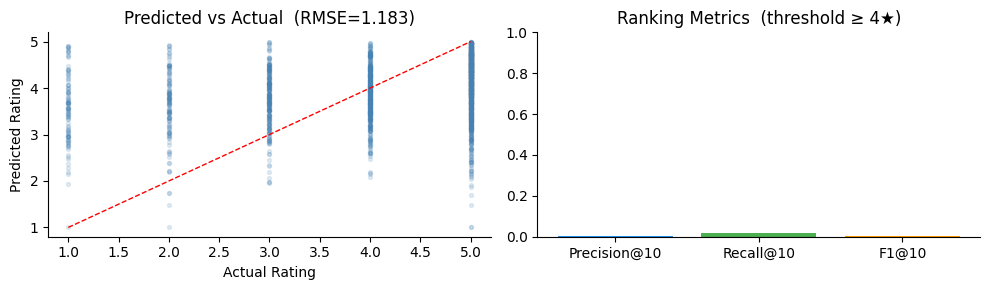

In [23]:
# ── Cell 10 · Visualise Metrics ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
# Predicted vs Actual (sample 2000)
sample = test_df.sample(min(2000, len(test_df)), random_state=1)
preds  = [model.predict(r.user_idx, r.product_idx) for r in sample.itertuples(index=False)]
axes[0].scatter(sample["Rating"], preds, alpha=0.15, s=8, color="steelblue")
axes[0].plot([1, 5], [1, 5], "r--", linewidth=1)
axes[0].set_xlabel("Actual Rating")
axes[0].set_ylabel("Predicted Rating")
axes[0].set_title(f"Predicted vs Actual  (RMSE={rmse:.3f})")

# Precision / Recall bar
axes[1].bar(["Precision@10", "Recall@10", "F1@10"],
            [p10, r10, f1], color=["#2196F3", "#4CAF50", "#FF9800"])
axes[1].set_ylim(0, 1)
axes[1].set_title("Ranking Metrics  (threshold ≥ 4★)")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()


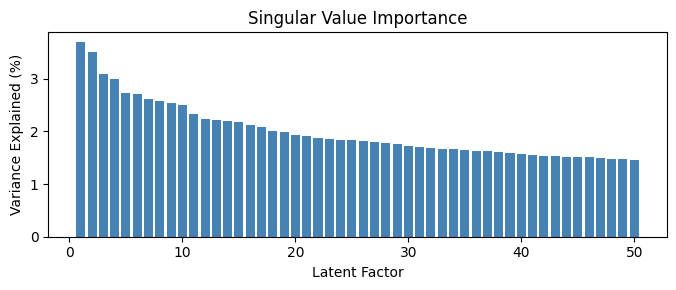

Top-5 factors explain 16.0% of variance


In [24]:
# ── Cell 11 · Singular Value Importance ──────────────────────
plt.figure(figsize=(7, 3))
explained = model.sigma ** 2
explained_pct = explained / explained.sum() * 100
plt.bar(range(1, len(explained_pct) + 1), explained_pct, color="steelblue")
plt.xlabel("Latent Factor")
plt.ylabel("Variance Explained (%)")
plt.title("Singular Value Importance")
plt.tight_layout()
plt.show()
print(f"Top-5 factors explain {explained_pct[:5].sum():.1f}% of variance")


In [25]:
# ── Cell 12 · Get Recommendations ────────────────────────────
def get_recommendations(user_id: str, top_n: int = 10,
                         verbose: bool = True) -> pd.DataFrame:
    """
    Return top-N unseen product recommendations for a given user.

    Parameters
    ----------
    user_id : str    – original UserId string
    top_n   : int    – number of recommendations
    verbose : bool   – print result table
    """
    if user_id not in user2idx:
        print(f"⚠️  User '{user_id}' not found.")
        return pd.DataFrame()

    uid   = user2idx[user_id]
    rated = set(train_df[train_df["user_idx"] == uid]["product_idx"])
    recs  = model.recommend(uid, top_n=top_n, exclude=rated)

    result = pd.DataFrame(recs, columns=["product_idx", "predicted_score"])
    result["ProductId"] = result["product_idx"].map(idx2product)
    result = result[["ProductId", "predicted_score"]]
    result.index = range(1, len(result) + 1)

    if verbose:
        print(f"\n🎯 Top-{top_n} recommendations for '{user_id}':")
        print(result.to_string())
    return result


In [26]:
# ── Cell 13 · Similar Products ───────────────────────────────
def similar_products(product_id: str, top_n: int = 5) -> pd.DataFrame:
    """
    Return products most similar to product_id in latent factor space.
    """
    if product_id not in product2idx:
        print(f"⚠️  Product '{product_id}' not found.")
        return pd.DataFrame()

    pidx     = product2idx[product_id]
    sim_idxs = model.top_factor_products(pidx, top_n=top_n)
    result   = pd.DataFrame({
        "ProductId": [idx2product[i] for i in sim_idxs],
    })
    result.index = range(1, len(result) + 1)
    print(f"\n🔗 Products similar to '{product_id}':")
    print(result.to_string())
    return result


In [27]:
# ── Cell 14 · Demo ───────────────────────────────────────────
demo_user    = df["UserId"].value_counts().index[0]   # most active user
demo_product = df["ProductId"].value_counts().index[0] # most rated product

recs = get_recommendations(demo_user, top_n=10)
sims = similar_products(demo_product, top_n=5)



🎯 Top-10 recommendations for 'A2V5R832QCSOMX':
     ProductId  predicted_score
1   B00639DLV2            4.402
2   B00H2B2RLK            4.362
3   B00AHF1GTM            4.294
4   B002WTC37A            4.275
5   B000WYZ9Q4            4.249
6   B00016XJ4M            4.241
7   B00CBD0M8Y            4.237
8   B004FKD3HI            4.221
9   B0002JKPA4            4.218
10  B00AE07BI0            4.212

🔗 Products similar to 'B004OHQR1Q':
    ProductId
1  B002M3KEOU
2  B00ANTDQL8
3  B00GMQDN64
4  B003C1V814
5  B004KRV8MS


In [28]:
# ── Cell 15 · Batch Recommendations (all users) ──────────────
def batch_recommend(top_n: int = 10) -> pd.DataFrame:
    """Generate recommendations for every user in the training set."""
    rows = []
    all_users = train_df["user_idx"].unique()
    for uid in all_users:
        rated = set(train_df[train_df["user_idx"] == uid]["product_idx"])
        for pidx, score in model.recommend(uid, top_n=top_n, exclude=rated):
            rows.append({
                "UserId":          idx2user[uid],
                "ProductId":       idx2product[pidx],
                "predicted_score": score,
                "rank":            len(rows) % top_n + 1,
            })
    return pd.DataFrame(rows)


In [29]:
print("\nGenerating batch recommendations…")
batch_recs = batch_recommend(top_n=10)
print(f"Total recommendation rows: {len(batch_recs):,}")
print(batch_recs.head(10).to_string(index=False))

# Optionally save to CSV
# batch_recs.to_csv("recommendations.csv", index=False)
# print("Saved → recommendations.csv")


print("\n✅ SVD Recommendation System complete!")


Generating batch recommendations…
Total recommendation rows: 223,620
       UserId  ProductId  predicted_score  rank
AY6THRAIFYK1T B005BF1M10            4.622     1
AY6THRAIFYK1T B00016XJ4M            4.551     2
AY6THRAIFYK1T B008USRW4Q            4.539     3
AY6THRAIFYK1T B007BJ3KQ4            4.539     4
AY6THRAIFYK1T B006SVCY6I            4.538     5
AY6THRAIFYK1T B007EHWDTS            4.537     6
AY6THRAIFYK1T B00ANL6RDU            4.533     7
AY6THRAIFYK1T B008U1Q4DI            4.530     8
AY6THRAIFYK1T B0030HKJ8I            4.529     9
AY6THRAIFYK1T B007L86026            4.529    10

✅ SVD Recommendation System complete!
